WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]


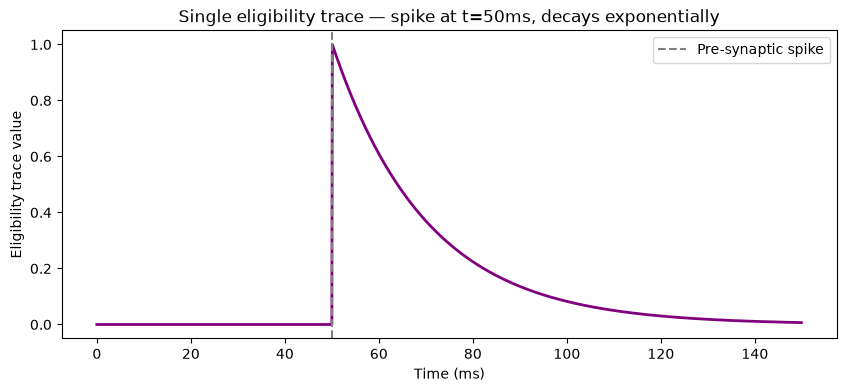

Trace value at spike (t=50ms): 0.0000
Trace value 20ms later (t=70ms): 0.3697
Trace value 40ms later (t=90ms): 0.1360


In [2]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

tau_trace = 20*ms

pre_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)

trace_eqs = '''
detrace/dt = -etrace/tau_trace : 1
'''

trace_holder = NeuronGroup(1, trace_eqs, method='exact')
trace_holder.etrace = 0

S = Synapses(pre_neuron, trace_holder, on_pre='etrace_post += 1.0')
S.connect()

trace_mon = StateMonitor(trace_holder, 'etrace', record=True)
spike_mon = SpikeMonitor(pre_neuron)

run(150*ms)

plt.figure(figsize=(10, 4))
plt.plot(trace_mon.t/ms, trace_mon.etrace[0], color='purple', linewidth=2)
plt.axvline(x=50, color='gray', linestyle='--', label='Pre-synaptic spike')
plt.xlabel('Time (ms)')
plt.ylabel('Eligibility trace value')
plt.title('Single eligibility trace — spike at t=50ms, decays exponentially')
plt.legend()
plt.show()

print(f"Trace value at spike (t=50ms): {trace_mon.etrace[0][int(50/0.1)]:.4f}")
print(f"Trace value 20ms later (t=70ms): {trace_mon.etrace[0][int(70/0.1)]:.4f}")
print(f"Trace value 40ms later (t=90ms): {trace_mon.etrace[0][int(90/0.1)]:.4f}")

In [3]:
peak_value = max(trace_mon.etrace[0])
peak_time = trace_mon.t[np.argmax(trace_mon.etrace[0])]/ms
print(f"Peak trace value: {peak_value:.4f} at t={peak_time:.1f}ms")

Peak trace value: 1.0000 at t=50.1ms


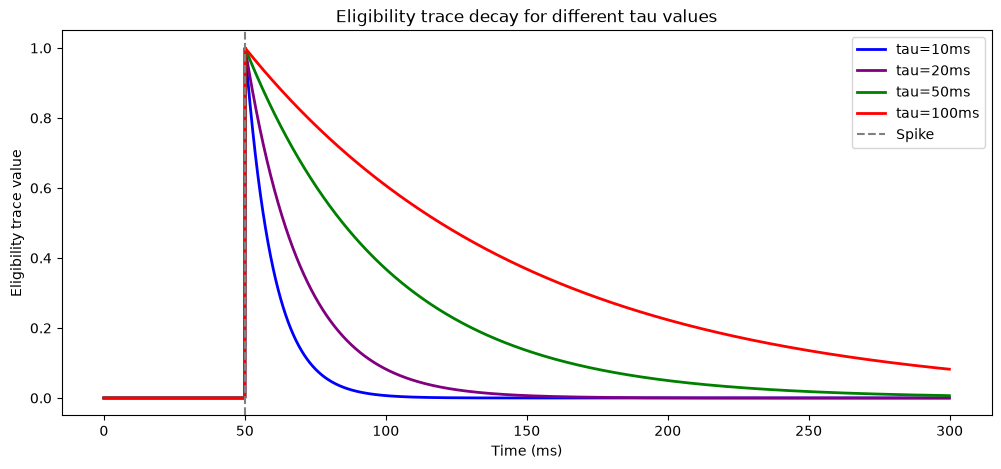

In [4]:
start_scope()

taus = [10, 20, 50, 100]*ms
colors = ['blue', 'purple', 'green', 'red']

plt.figure(figsize=(12, 5))

for tau_val, color in zip(taus, colors):
    start_scope()
    
    tau_trace = tau_val
    pre_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    trace_eqs = '''
    detrace/dt = -etrace/tau_trace : 1
    '''
    
    trace_holder = NeuronGroup(1, trace_eqs, method='exact')
    trace_holder.etrace = 0
    
    S = Synapses(pre_neuron, trace_holder, on_pre='etrace_post += 1.0')
    S.connect()
    
    trace_mon = StateMonitor(trace_holder, 'etrace', record=True)
    run(300*ms)
    
    plt.plot(trace_mon.t/ms, trace_mon.etrace[0], 
             color=color, linewidth=2, 
             label=f'tau={int(tau_val/ms)}ms')

plt.axvline(x=50, color='gray', linestyle='--', label='Spike')
plt.xlabel('Time (ms)')
plt.ylabel('Eligibility trace value')
plt.title('Eligibility trace decay for different tau values')
plt.legend()
plt.show()

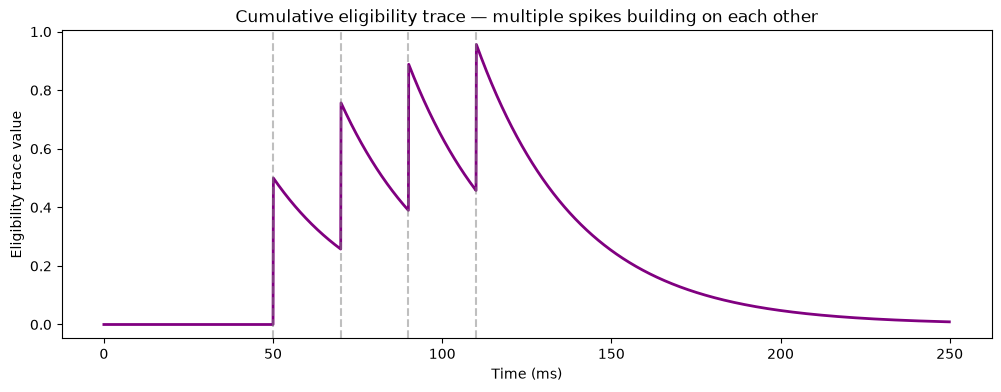

Peak cumulative trace value: 0.9562
Single spike peak would have been: 0.5000
Cumulative amplification: 1.91x


In [7]:
start_scope()

tau_trace = 30*ms

# Pre neuron fires 4 times in quick succession
pre_neuron = SpikeGeneratorGroup(1, [0]*4, [50, 70, 90, 110]*ms)

trace_eqs = '''
detrace/dt = -etrace/tau_trace : 1
'''

trace_holder = NeuronGroup(1, trace_eqs, method='exact')
trace_holder.etrace = 0

S = Synapses(pre_neuron, trace_holder, on_pre='etrace_post += 0.5')
S.connect()

trace_mon = StateMonitor(trace_holder, 'etrace', record=True)
spike_mon = SpikeMonitor(pre_neuron)

run(250*ms)

plt.figure(figsize=(12, 4))
plt.plot(trace_mon.t/ms, trace_mon.etrace[0], color='purple', linewidth=2)
for t in [50, 70, 90, 110]:
    plt.axvline(x=t, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Time (ms)')
plt.ylabel('Eligibility trace value')
plt.title('Cumulative eligibility trace — multiple spikes building on each other')
plt.show()

peak = max(trace_mon.etrace[0])
print(f"Peak cumulative trace value: {peak:.4f}")
print(f"Single spike peak would have been: 0.5000")
print(f"Cumulative amplification: {peak/0.5:.2f}x")

## Eligibility Traces — Observations & Results

### Why eligibility traces?
Eligibility traces are the core mechanism underlying both reward-modulated 
STDP (notebook 09) and e-prop — the more advanced learning algorithm 
identified in the reading log's first paper as a key direction for scalable 
neuromorphic learning. This notebook isolates and characterises the trace 
mechanism itself before incorporating reward signals in the next notebook, notebook 11.

### What is an eligibility trace?
An eligibility trace is a synapse-local, decaying memory of recent spike coincidences. When a 
pre-synaptic spike occurs, the trace spikes up sharply, then decays 
exponentially over time, regardless of whether a reward arrives or not. 
The trace represents the synapse saying: *"I did something recently that 
might deserve credit, if a reward arrives before I forget."*

When a delayed reward signal eventually arrives, it multiplies against 
whatever trace remains:
weight change = reward × eligibility trace

The recent coincidences (strong trace) get full credit, while the old coincidences 
(decayed trace) get partial credit. No coincidences (zero trace) get
nothing, even with a strong reward.

### Key finding 1: discrete-time sampling artifact
The trace monitor recorded `etrace = 0.0000` at exactly t=50ms (the spike 
timestamp), despite the spike occurring there. Probing the actual peak:
Peak trace value: 1.0000 at t=50.1ms

The trace reaches its true peak one timestep (0.1ms) after the spike, which is
consistent with the discrete-time delay documented in notebooks 06, 07, 
and earlier Brian2 work. The state is recorded *before* the spike's effect 
is applied within that timestep.

### Key finding 2: tau controls the credit assignment window
Sweeping tau across four values revealed how trace duration scales directly 
with tau:

| tau | Approximate duration trace remains meaningful |
|-----|----------------------------------------------|
| 10ms | ~30ms after spike |
| 20ms | ~60ms after spike |
| 50ms | ~150ms after spike |
| 100ms | ~300ms after spike |

**Implication for reward timing:** the tau value sets a hard upper bound on 
how delayed a reward can be and still produce meaningful learning. Biological dopamine signals arrive with delays of hundreds of milliseconds, 
implying biological eligibility traces must last on the order of seconds — 
consistent with experimental estimates from in-vivo recordings.

### Key finding 3: cumulative amplification from multiple spikes
With 4 spikes fired in quick succession (t=50, 70, 90, 110ms), each adding 
0.5 to the existing trace before it fully decayed:

| Metric | Value |
|--------|-------|
| Single spike peak | 0.5000 |
| Cumulative peak (4 spikes) | 0.9562 |
| Amplification factor | 1.91x |

The trace accumulated into a wave shape with each spike adding to a partially 
decayed residual from the previous one, producing a cumulative value nearly 
twice that of a single spike. When the reward arrives, it implies that recently and 
repeatedly active synapses receive proportionally stronger weight updates 
than synapses that fired only once.

**Biological connection:** this cumulative amplification is thought to 
underlie why repeated rehearsal strengthens memories more than a single 
exposure, where each repetition adds to the eligibility trace before it fully 
decays, producing stronger synaptic consolidation when neuromodulatory 
signals arrive.

### What's next? (notebook 11)
Now that the trace mechanism is understood in isolation, notebook 11 will 
add a delayed reward signal and demonstrate temporal credit assignment,
showing how learning degrades as the delay between spike coincidence and 
reward arrival increases, and confirming that tau sets the upper bound on 
useful reward delay.